In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('Superstore.csv', encoding='latin1')

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [ ]:
df['YearMonth'] = df['Order Date'].dt.to_period('M')

In [ ]:
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

In [ ]:
monthly_sales.head()

,Sales
YearMonth,
2014-01,14236.895
2014-02,4519.892
2014-03,55691.009
2014-04,28295.345
2014-05,23648.287


In [ ]:
import matplotlib.pyplot as plt

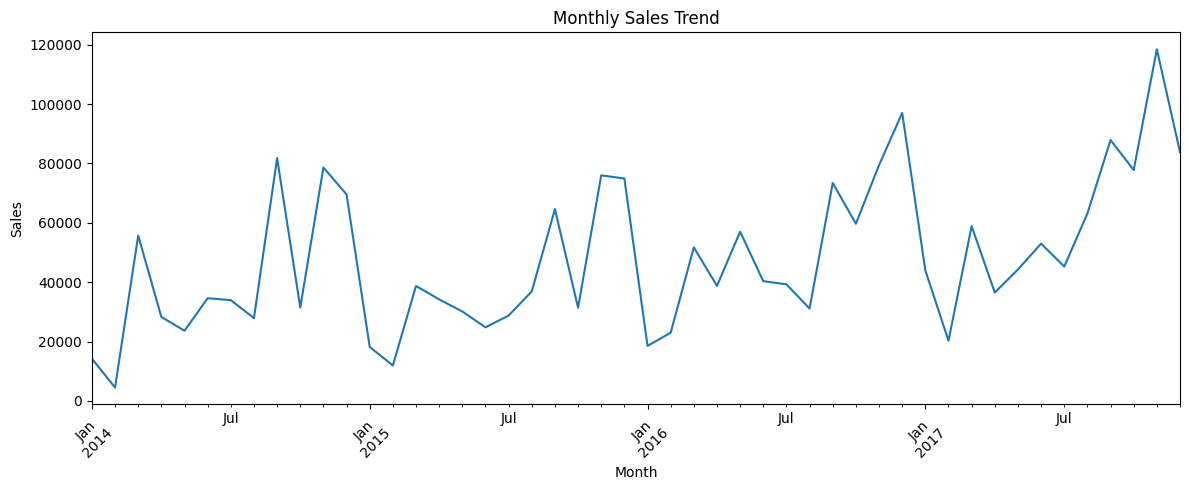

In [ ]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Insight: Sales Trend

The monthly sales trend shows an overall upward movement over time, indicating gradual business growth. However, the trend is highly fluctuating with multiple peaks and drops. Some mid-year periods (around June–July) show noticeable declines, suggesting possible seasonal variations in demand.

In [ ]:
monthly_sales.max()

118447.825

In [ ]:
monthly_sales.min()

4519.892

In [21]:
category_sales = df.groupby('Category')['Sales'].sum()
category_sales

,Sales
Category,
Furniture,741999.7953
Office Supplies,719047.0320
Technology,836154.0330


#Insight: Category Analysis

Among all product categories, Technology generates the highest sales, indicating strong customer demand for tech-related products. Furniture and Office Supplies follow, but with comparatively lower sales, suggesting that Technology is the primary revenue-driving category.

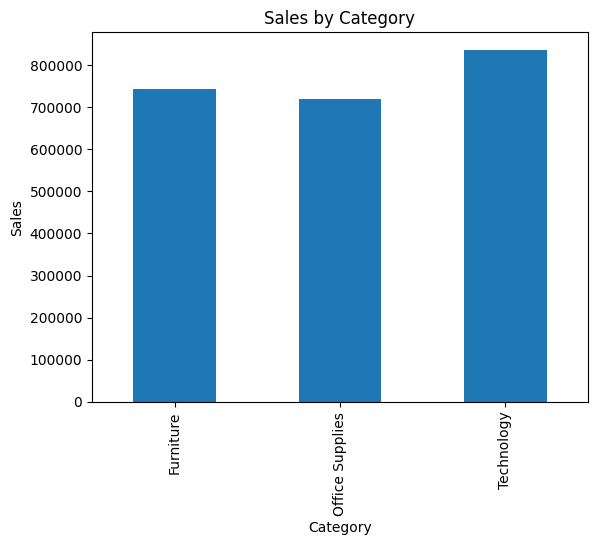

In [22]:
category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')

plt.show()

In [23]:
sub_category_sales = df.groupby('Sub-Category')['Sales'].sum()
sub_category_sales.sort_values(ascending=False)

,Sales
Sub-Category,
Phones,330007.0540
Chairs,328449.1030
Storage,223843.6080
Tables,206965.5320
Binders,203412.7330
Machines,189238.6310
Accessories,167380.3180
Copiers,149528.0300
Bookcases,114879.9963


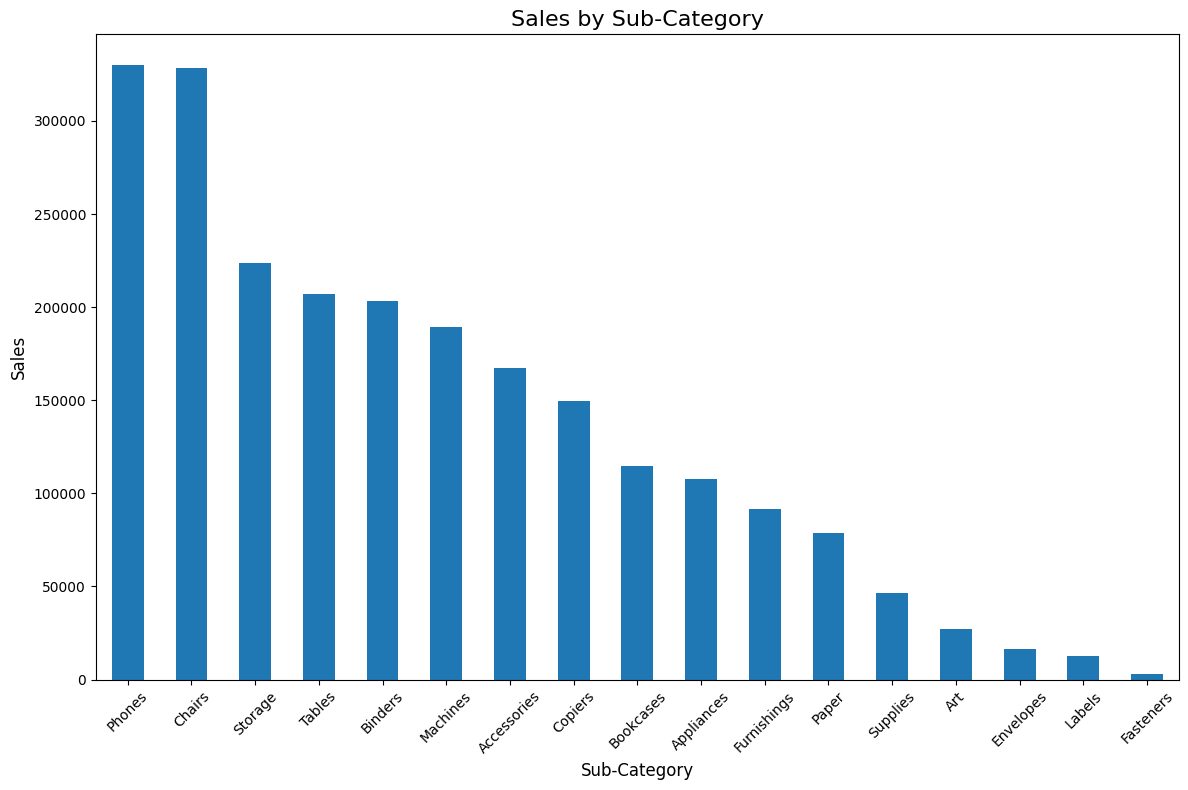

In [34]:
plt.figure(figsize=(12,8))

sub_category_sales.sort_values(ascending=False).plot(kind='bar')

plt.title('Sales by Sub-Category', fontsize=16)
plt.xlabel('Sub-Category', fontsize=12)
plt.ylabel('Sales', fontsize=12)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

#Insight: Sub-Category Analysis

The sub-category analysis shows that Phones generate the highest sales, followed closely by Chairs and Storage. This indicates strong customer demand for communication devices and essential furniture/storage products. These sub-categories contribute significantly to overall revenue.

#Final Conclusion

The analysis reveals that sales show an overall increasing trend over time with noticeable fluctuations. Technology is the highest revenue-generating category, while Phones, Chairs, and Storage are the top-performing sub-categories. These insights indicate strong demand for technology and essential products, suggesting that focusing on these areas can drive business growth.